# WM 2026 — Prognose-Auswertung (Backtest gegen echte Ergebnisse)

Begleit-Notebook zu *Soccer Analytics with Machine Learning* (O'Reilly, 2026).

Dieses Notebook nimmt die **Match-Prognosen aus `wc2026_live_update.ipynb`** und
vergleicht sie **chronologisch mit den echten WM-2026-Ergebnissen**. Für jedes
bereits gespielte Spiel zeigen wir:

* **Sieg / Unentschieden / Niederlage** — welche Tendenz war getippt, und war sie **richtig**? ✓ / ✗
* **Exaktes Ergebnis** — wurde der wahrscheinlichste Spielstand (z. B. `1:0`) **getroffen**? ✓ / ✗
* **Ø Tore (λ)** — wie nah lagen die erwarteten Tore an den tatsächlich erzielten?

> **Hinweis:** Die Match-Prognosen des Live-Notebooks sind *statisch* — sie hängen
> nur an der Modell-Kalibrierung (358 historische Spiele, rein vor dem Turnier),
> nicht an WM-Ergebnissen. Der Test ist damit ein **sauberer Out-of-sample-Test**.
> Das Notebook nutzt die gespeicherten `results/*_next_matches.csv`, falls
> vorhanden, und reproduziert sie sonst mit demselben Modell.

## 1. Setup & identischer Modell-Kern wie im Live-Notebook

Dieselbe Kalibrierung (Poisson + Negative Binomial + Elo/Colley/PageRank) und
dieselben Funktionen `lam` (erwartete Tore), `wdl_consensus` (Sieg/Remis/Niederlage
aus 5 Modellen) und `modal_score` (wahrscheinlichstes exaktes Ergebnis).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import glob
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from scipy.stats import poisson as pois, nbinom
import statsmodels.api as sm
from collections import defaultdict, deque

DATA = Path("data")
NAVY, RED, GREEN, AMBER, GREY = "#1E2761", "#B85042", "#2E7D5B", "#E0A040", "#8A8D93"
mpl.rcParams.update({"font.family":"DejaVu Sans","font.size":11,"axes.spines.top":False,
    "axes.spines.right":False,"axes.titleweight":"bold","figure.dpi":110,
    "savefig.dpi":150,"savefig.bbox":"tight"})

GROUPS = {
    "A":["Mexico","South Africa","South Korea","Czechia"],"B":["Canada","Bosnia-Herzegovina","Qatar","Switzerland"],
    "C":["Brazil","Morocco","Haiti","Scotland"],"D":["United States","Paraguay","Australia","Türkiye"],
    "E":["Germany","Curacao","Ivory Coast","Ecuador"],"F":["Netherlands","Japan","Sweden","Tunisia"],
    "G":["Belgium","Egypt","Iran","New Zealand"],"H":["Spain","Cape Verde","Saudi Arabia","Uruguay"],
    "I":["France","Senegal","Iraq","Norway"],"J":["Argentina","Algeria","Austria","Jordan"],
    "K":["Portugal","Congo DR","Uzbekistan","Colombia"],"L":["England","Croatia","Ghana","Panama"],
}
TEAMS = [t for g in GROUPS.values() for t in g]
STRENGTH = {
    "Spain":2165,"Argentina":2120,"France":2100,"England":2055,"Brazil":2025,"Netherlands":2030,
    "Portugal":2010,"Germany":1965,"Belgium":1950,"Croatia":1945,"Uruguay":1930,"Colombia":1915,
    "Morocco":1900,"Japan":1900,"Senegal":1895,"Switzerland":1860,"Norway":1855,"Austria":1850,
    "Ecuador":1840,"Türkiye":1840,"Mexico":1820,"Czechia":1815,"Sweden":1815,"United States":1805,
    "Iran":1800,"Ivory Coast":1800,"Algeria":1795,"South Korea":1790,"Scotland":1780,"Egypt":1780,
    "Canada":1780,"Ghana":1750,"Paraguay":1720,"Australia":1720,"Congo DR":1720,"Bosnia-Herzegovina":1710,
    "Tunisia":1700,"Qatar":1680,"Uzbekistan":1680,"Saudi Arabia":1655,"Iraq":1650,"Panama":1650,
    "South Africa":1640,"Jordan":1600,"Cape Verde":1555,"Curacao":1530,"Haiti":1500,"New Zealand":1500,
    "Italy":1990,"Denmark":1870,"Poland":1825,"Serbia":1820,"Chile":1815,"Russia":1815,"Nigeria":1810,
    "Ukraine":1800,"Greece":1800,"Hungary":1795,"Wales":1790,"Cameroon":1760,"Slovakia":1760,
    "Slovenia":1760,"Romania":1755,"Peru":1750,"Iceland":1740,"Georgia":1735,"Albania":1730,
    "North Macedonia":1720,"Finland":1715,"Costa Rica":1700,"Honduras":1620,"North Korea":1600,
}
COLS = ["home_team","away_team","home_score","away_score"]
M = pd.concat([pd.read_csv(DATA/"worldcup_matches.csv")[COLS],
               pd.read_csv(DATA/"recent_internationals.csv")[COLS]], ignore_index=True)
M = M[M.home_team.isin(STRENGTH) & M.away_team.isin(STRENGTH)].copy()
M["sdiff"] = M.home_team.map(STRENGTH) - M.away_team.map(STRENGTH)
M["res"]   = np.sign(M.home_score - M.away_score).astype(int)
gl = pd.DataFrame({"goals": np.r_[M.home_score, M.away_score], "sd": np.r_[M.sdiff, -M.sdiff]})
pf = sm.GLM(gl.goals, sm.add_constant(gl[["sd"]]), family=sm.families.Poisson()).fit()
B0, B1 = pf.params["const"], pf.params["sd"]
alpha = max(1e-3, (pf.pearson_chi2/pf.df_resid - 1))
dz = sm.add_constant(pd.DataFrame({"abs": M.sdiff.abs()}))
drf = sm.GLM((M.res==0).astype(int), dz, family=sm.families.Binomial()).fit()
def pdraw(absd): return float(drf.predict(sm.add_constant(pd.DataFrame({"abs":[absd]}), has_constant="add"))[0])

def lam(a, b, R=STRENGTH): d = R[a]-R[b]; return float(np.exp(B0+B1*d)), float(np.exp(B0-B1*d))
def scoreline(a, b, R=STRENGTH, disp=0.0, maxg=7):
    la, lb = lam(a, b, R); g = np.arange(maxg+1)
    def pmf(l):
        if disp > 1e-6: rr = 1/disp; return nbinom.pmf(g, rr, rr/(rr+l))
        return pois.pmf(g, l)
    P = np.outer(pmf(la), pmf(lb)); P /= P.sum(); return P
def wdl(a, b, R=STRENGTH):
    P = scoreline(a, b, R); return np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()
def modal_score(a, b, R=STRENGTH):
    P = scoreline(a, b, R); n = P.shape[0]; i, j = divmod(int(np.argmax(P)), n); return f"{i}:{j}"

def _ratings(kind):
    teams = sorted(set(M.home_team)|set(M.away_team)); idx={t:i for i,t in enumerate(teams)}; n=len(teams)
    if kind == "colley":
        C=np.eye(n)*2; b=np.ones(n)
        for _,r in M.iterrows():
            i,j=idx[r.home_team],idx[r.away_team]; C[i,i]+=1;C[j,j]+=1;C[i,j]-=1;C[j,i]-=1
            wi=1.0 if r.res>0 else (0.5 if r.res==0 else 0.0); b[i]+=wi-0.5;b[j]+=(1-wi)-0.5
        x=np.linalg.solve(C,b); raw={t:x[idx[t]] for t in teams}
    else:
        W=np.zeros((n,n))
        for _,r in M.iterrows():
            i,j=idx[r.home_team],idx[r.away_team]
            if r.res>0:W[j,i]+=1
            elif r.res<0:W[i,j]+=1
            else:W[i,j]+=.5;W[j,i]+=.5
        cs=W.sum(1,keepdims=True);cs[cs==0]=1;T=W/cs;pr=np.ones(n)/n
        for _ in range(100): pr=0.15/n+0.85*(T.T@pr)
        raw={t:pr[idx[t]] for t in teams}
    v=np.array(list(raw.values())); mu,sd=v.mean(),v.std()+1e-9
    return {t:(1850+(raw[t]-mu)/sd*130) if t in raw else STRENGTH[t] for t in TEAMS}
COLLEY, PAGER = _ratings("colley"), _ratings("pagerank")

def wdl_consensus(a, b, R=STRENGTH):
    # Mittel aus 5 Modellen (wie im Live-Notebook); R = Stärke-Basis (statisch oder laufend)
    mods = [wdl(a,b,R)]
    P = scoreline(a,b,R,alpha); mods.append((np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()))
    da = R[a]-R[b]; we = 1/(1+10**(-da/400)); pdr = pdraw(abs(da))
    mods.append(((1-pdr)*we, pdr, (1-pdr)*(1-we)))
    mods.append(wdl(a,b,COLLEY)); mods.append(wdl(a,b,PAGER))
    arr = np.array(mods).mean(0); return tuple(arr/arr.sum())
print(f"Modell-Kern bereit (kalibriert auf {len(M)} historischen Spielen).")

Modell-Kern bereit (kalibriert auf 358 historischen Spielen).


## 2. Echte Ergebnisse & gespeicherte Live-Prognosen laden

Die echten, bereits gespielten WM-Spiele kommen aus `data/wc2026_results.csv`
(mit `python refresh_data.py` aktualisierbar). Zusätzlich suchen wir die vom
Live-Notebook gespeicherten Prognose-Schnappschüsse `results/*_next_matches.csv`.

In [2]:
NAME_MAP = {"Czech Republic":"Czechia","Bosnia & Herzegovina":"Bosnia-Herzegovina","Turkey":"Türkiye",
            "USA":"United States","Curaçao":"Curacao","DR Congo":"Congo DR"}
def nm(t): return NAME_MAP.get(t, t)

res = pd.read_csv(DATA/"wc2026_results.csv")
played = res[res.score1.notna() & res.group.notna()].copy()
played["home"] = played.team1.map(nm); played["away"] = played.team2.map(nm)
played = played[played.home.isin(STRENGTH) & played.away.isin(STRENGTH)].sort_values("date").reset_index(drop=True)

# gespeicherte Live-Prognosen (statisch -> erste Fundstelle je Begegnung genügt)
saved = {}
snap_files = sorted(glob.glob("results/*_next_matches.csv"))
for f in snap_files:
    df = pd.read_csv(f)
    for _, r in df.iterrows():
        b = str(r.get("Begegnung", ""))
        if " – " not in b: continue
        h, a = [x.strip() for x in b.split(" – ")]
        if (h, a) in saved: continue
        try:
            lh, la = [float(x) for x in str(r["Ø Tore (λ)"]).split(" : ")]
            saved[(h, a)] = dict(lam_h=lh, lam_a=la, p_w=float(r["P(Sieg 1)"]),
                                 p_d=float(r["P(Remis)"]), p_l=float(r["P(Sieg 2)"]),
                                 modal=str(r["wahrsch. Erg."]))
        except Exception:
            pass
print(f"Gespielte WM-Spiele zum Auswerten: {len(played)}")
print(f"Gespeicherte Live-Prognose-Schnappschüsse: {len(snap_files)}  ->  {len(saved)} eindeutige Begegnungen")

Gespielte WM-Spiele zum Auswerten: 29
Gespeicherte Live-Prognose-Schnappschüsse: 2  ->  51 eindeutige Begegnungen


## 3. Prognose-Log: Vorhersage vs. Realität je Spiel

Für jedes gespielte Spiel holen wir die Prognose (aus dem Live-Snapshot, falls
vorhanden; sonst identisch reproduziert) und vergleichen sie mit dem echten
Endstand. `Tendenz` = die getippte Mehrheit aus Sieg/Remis/Niederlage.

In [3]:
LBL = {1:"Heimsieg", 0:"Remis", -1:"Auswärtssieg"}

def predict(home, away):
    if (home, away) in saved:
        s = saved[(home, away)]; src = "Live-Snapshot"
        return s["lam_h"], s["lam_a"], s["p_w"]/100, s["p_d"]/100, s["p_l"]/100, s["modal"], src
    lh, la = lam(home, away); w, d, l = wdl_consensus(home, away)
    return lh, la, w, d, l, modal_score(home, away), "reproduziert"

rows = []
for _, m in played.iterrows():
    h, a, gh, ga = m.home, m.away, int(m.score1), int(m.score2)
    lh, la, w, d, l, modal, src = predict(h, a)
    probs = np.array([w, d, l]); ti = int(np.argmax(probs)); tend_pred = [1,0,-1][ti]
    tend_act = int(np.sign(gh - ga))
    rows.append(dict(
        Datum=m.date, Begegnung=f"{h} – {a}", src=src,
        lam_h=lh, lam_a=la, gh=gh, ga=ga,
        lam_str=f"{lh:.1f} : {la:.1f}", endstand=f"{gh}:{ga}",
        lam_err=abs(lh-gh)+abs(la-ga),
        tipp=f"{LBL[tend_pred]} {probs[ti]*100:.0f}%",
        tend_pred=tend_pred, tend_act=tend_act, p_w=w, p_d=d, p_l=l,
        wdl_ok=(tend_pred==tend_act), modal=modal, score_ok=(modal==f"{gh}:{ga}")))
ev = pd.DataFrame(rows)
print(f"{len(ev)} Spiele ausgewertet.  Quelle der Prognosen: "
      + ", ".join(f"{k}={v}" for k, v in ev.src.value_counts().items()))

29 Spiele ausgewertet.  Quelle der Prognosen: reproduziert=21, Live-Snapshot=8


### 3b. Chronologische Detailtabelle

In [4]:
det = pd.DataFrame({
    "Datum": ev.Datum, "Begegnung": ev.Begegnung,
    "λ-Prognose": ev.lam_str, "Endstand": ev.endstand,
    "λ-Fehler": ev.lam_err.round(2),
    "Tipp (W/U/N)": ev.tipp, "Tendenz": np.where(ev.wdl_ok, "✓", "✗"),
    "Modus-Tipp": ev.modal, "Ergebnis": np.where(ev.score_ok, "✓", "✗"),
})
def _mark(v):
    return ("background-color:#d7e9d2;color:#1b5e20;font-weight:bold" if v=="✓"
            else "background-color:#f6d4cf;color:#8a2a1f;font-weight:bold" if v=="✗" else "")
(det.style.hide(axis="index")
   .map(_mark, subset=["Tendenz","Ergebnis"])
   .background_gradient(cmap="Reds", subset=["λ-Fehler"])
   .set_caption("Prognose vs. Realität je Spiel — Tendenz ✓/✗ (Sieg/Remis/Niederlage), "
                "Ergebnis ✓/✗ (exakter Spielstand), λ = erwartete Tore"))

Datum,Begegnung,λ-Prognose,Endstand,λ-Fehler,Tipp (W/U/N),Tendenz,Modus-Tipp,Ergebnis
2026-06-11,Mexico – South Africa,1.6 : 0.9,2:0,1.290000,Heimsieg 49%,✓,1:0,✗
2026-06-11,South Korea – Czechia,1.1 : 1.2,2:1,1.100000,Auswärtssieg 38%,✗,1:1,✗
2026-06-12,Canada – Bosnia-Herzegovina,1.3 : 1.1,1:1,0.380000,Heimsieg 38%,✗,1:1,✓
2026-06-12,United States – Paraguay,1.4 : 1.0,4:1,2.670000,Heimsieg 43%,✓,1:1,✗
2026-06-13,Qatar – Switzerland,0.9 : 1.6,1:1,0.710000,Auswärtssieg 59%,✗,0:1,✗
2026-06-13,Australia – Türkiye,1.0 : 1.4,2:0,2.470000,Auswärtssieg 44%,✗,0:1,✗
2026-06-13,Brazil – Morocco,1.5 : 1.0,1:1,0.490000,Heimsieg 50%,✗,1:0,✗
2026-06-13,Haiti – Scotland,0.7 : 1.9,0:1,1.620000,Auswärtssieg 61%,✓,0:1,✓
2026-06-14,Sweden – Tunisia,1.4 : 1.0,5:1,3.590000,Heimsieg 48%,✓,1:0,✗
2026-06-14,Netherlands – Japan,1.5 : 1.0,2:2,1.580000,Heimsieg 54%,✗,1:0,✗


## 4. Vorhersagequalität — Kennzahlen

* **Tendenz-Trefferquote (WDL):** Anteil korrekt getippter Sieg/Remis/Niederlage.
* **Exakt-Ergebnis-Trefferquote:** Anteil exakt getroffener Spielstände.
* **λ-MAE:** mittlerer absoluter Fehler der erwarteten Tore (Heim + Auswärts).
* **Brier-Score** & **Log-Loss:** Güte der Wahrscheinlichkeiten (kleiner = besser).
* Zum Vergleich: **Zufall** (3 Klassen) und die Baseline **„immer Heimsieg"**.

In [5]:
n = len(ev)
oh = np.zeros((n,3)); oh[np.arange(n), [ {1:0,0:1,-1:2}[t] for t in ev.tend_act ]] = 1
P = ev[["p_w","p_d","p_l"]].values
brier = float(np.mean(np.sum((P-oh)**2, axis=1)))
logloss = float(-np.mean(np.log(np.clip(P[np.arange(n), oh.argmax(1)], 1e-6, 1))))
home_base = float((ev.tend_act==1).mean())

metrics = pd.DataFrame({
    "Kennzahl": ["Spiele ausgewertet","Tendenz-Trefferquote (WDL)","davon Zufallsniveau",
                 "Baseline „immer Heimsieg“","Exakt-Ergebnis-Trefferquote",
                 "λ-MAE Heim","λ-MAE Auswärts","λ-MAE gesamt (Heim+Ausw.)",
                 "Brier-Score (W/U/N)","Log-Loss (W/U/N)"],
    "Wert": [f"{n}", f"{ev.wdl_ok.mean()*100:.1f}%", "33.3%",
             f"{home_base*100:.1f}%", f"{ev.score_ok.mean()*100:.1f}%",
             f"{np.abs(ev.lam_h-ev.gh).mean():.2f}", f"{np.abs(ev.lam_a-ev.ga).mean():.2f}",
             f"{ev.lam_err.mean():.2f}", f"{brier:.3f}", f"{logloss:.3f}"],
})
print(f"Tendenz {ev.wdl_ok.sum()}/{n} ({ev.wdl_ok.mean()*100:.0f}%) · "
      f"exaktes Ergebnis {ev.score_ok.sum()}/{n} ({ev.score_ok.mean()*100:.0f}%)")
metrics.style.hide(axis="index").set_caption("Vorhersagequalität der Live-Prognosen am realen WM-Set")

Tendenz 16/29 (55%) · exaktes Ergebnis 2/29 (7%)


Kennzahl,Wert
Spiele ausgewertet,29
Tendenz-Trefferquote (WDL),55.2%
davon Zufallsniveau,33.3%
Baseline „immer Heimsieg“,55.2%
Exakt-Ergebnis-Trefferquote,6.9%
λ-MAE Heim,1.23
λ-MAE Auswärts,0.68
λ-MAE gesamt (Heim+Ausw.),1.92
Brier-Score (W/U/N),0.594
Log-Loss (W/U/N),0.981


## 5. Visualisierung der Vorhersagequalität

(1) kumulative Tendenz-Trefferquote über die Zeit · (2) erwartete λ vs. echte
Tore · (3) Tendenz-Konfusionsmatrix · (4) Kalibrierung (Ø-Prognose vs.
beobachtete Häufigkeit je Ausgang).

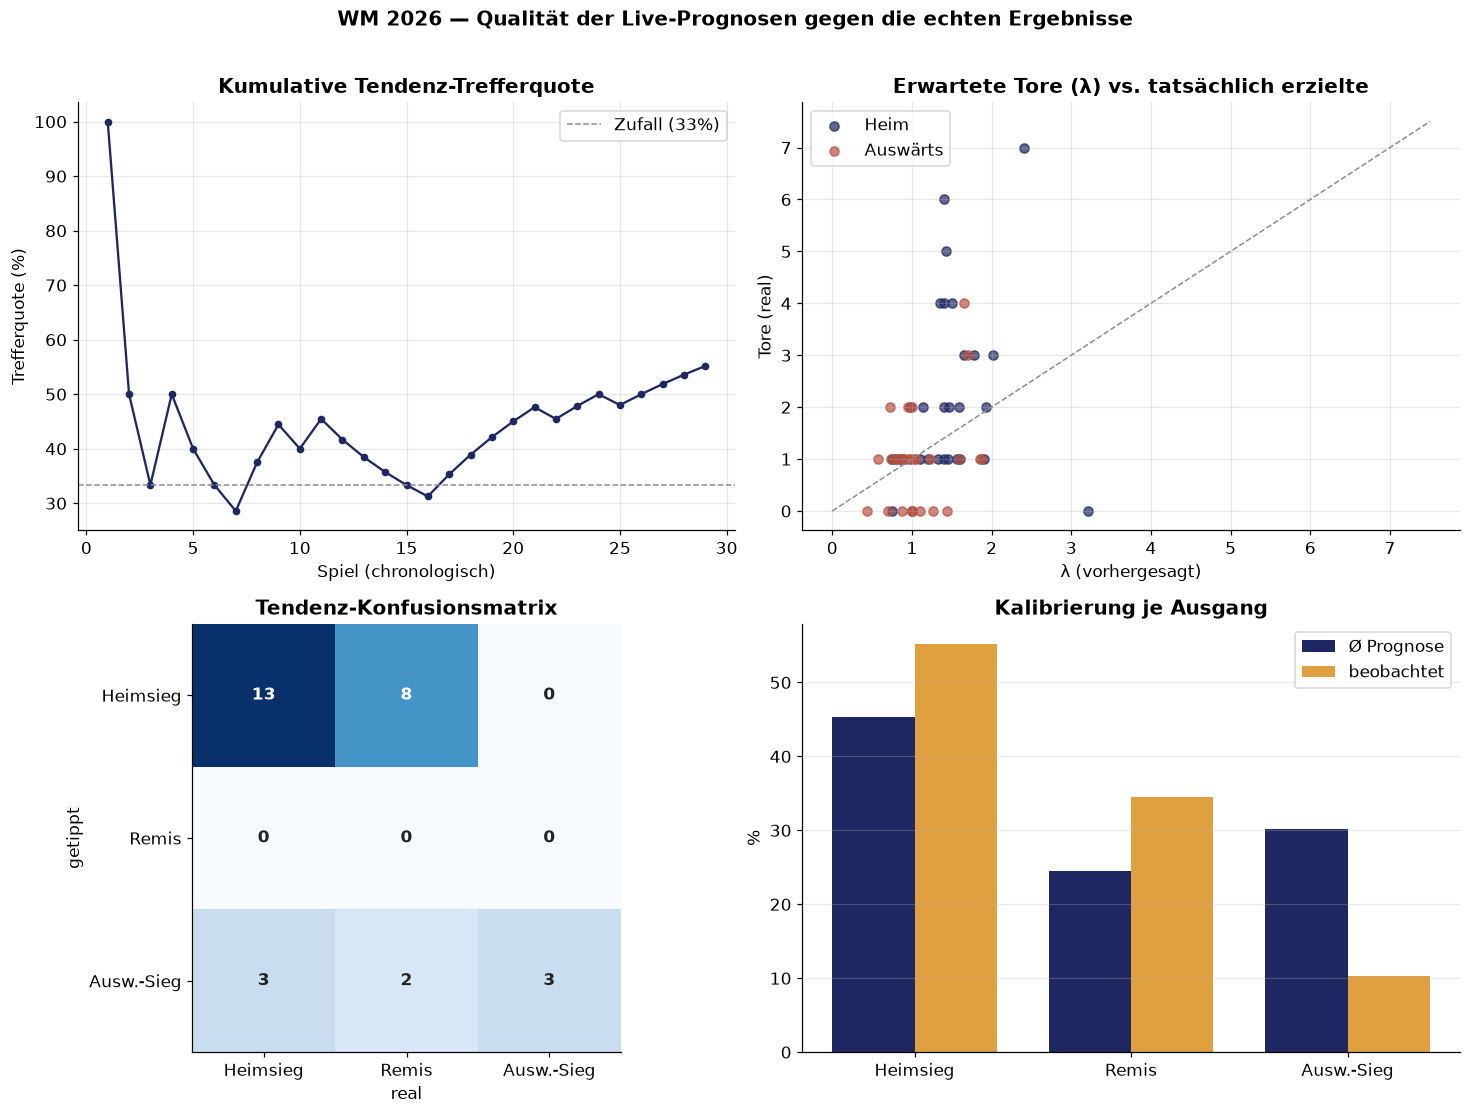

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(13.5, 10))

# (1) kumulative Trefferquote
cum = ev.wdl_ok.expanding().mean().values*100
ax[0,0].plot(range(1,n+1), cum, "-o", color=NAVY, ms=4)
ax[0,0].axhline(100/3, color=GREY, ls="--", lw=1, label="Zufall (33%)")
ax[0,0].set_title("Kumulative Tendenz-Trefferquote"); ax[0,0].set_xlabel("Spiel (chronologisch)")
ax[0,0].set_ylabel("Trefferquote (%)"); ax[0,0].legend(); ax[0,0].grid(alpha=.3)

# (2) lambda vs echte Tore
ax[0,1].scatter(ev.lam_h, ev.gh, color=NAVY, label="Heim", alpha=.7)
ax[0,1].scatter(ev.lam_a, ev.ga, color=RED, label="Auswärts", alpha=.7)
mx = max(ev.gh.max(), ev.ga.max(), 4)+0.5
ax[0,1].plot([0,mx],[0,mx], color=GREY, ls="--", lw=1)
ax[0,1].set_title("Erwartete Tore (λ) vs. tatsächlich erzielte")
ax[0,1].set_xlabel("λ (vorhergesagt)"); ax[0,1].set_ylabel("Tore (real)"); ax[0,1].legend(); ax[0,1].grid(alpha=.3)

# (3) Konfusionsmatrix Tendenz
order=[1,0,-1]; lab=["Heimsieg","Remis","Ausw.-Sieg"]
cm=np.zeros((3,3),int)
for tp,ta in zip(ev.tend_pred, ev.tend_act): cm[order.index(tp), order.index(ta)]+=1
im=ax[1,0].imshow(cm, cmap="Blues")
ax[1,0].set_xticks(range(3)); ax[1,0].set_xticklabels(lab); ax[1,0].set_yticks(range(3)); ax[1,0].set_yticklabels(lab)
ax[1,0].set_xlabel("real"); ax[1,0].set_ylabel("getippt"); ax[1,0].set_title("Tendenz-Konfusionsmatrix")
for i in range(3):
    for j in range(3): ax[1,0].text(j,i,cm[i,j],ha="center",va="center",
                                    color="white" if cm[i,j]>cm.max()*0.5 else "#222", fontweight="bold")

# (4) Kalibrierung: Ø vorhergesagte Wahrscheinlichkeit vs. beobachtete Häufigkeit
pred_avg=[ev.p_w.mean(), ev.p_d.mean(), ev.p_l.mean()]
obs_freq=[(ev.tend_act==1).mean(), (ev.tend_act==0).mean(), (ev.tend_act==-1).mean()]
x=np.arange(3); w=0.38
ax[1,1].bar(x-w/2, np.array(pred_avg)*100, w, color=NAVY, label="Ø Prognose")
ax[1,1].bar(x+w/2, np.array(obs_freq)*100, w, color=AMBER, label="beobachtet")
ax[1,1].set_xticks(x); ax[1,1].set_xticklabels(lab); ax[1,1].set_ylabel("%")
ax[1,1].set_title("Kalibrierung je Ausgang"); ax[1,1].legend(); ax[1,1].grid(axis="y", alpha=.3)

fig.suptitle("WM 2026 — Qualität der Live-Prognosen gegen die echten Ergebnisse",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("nb_eval_quality.png"); plt.show()

## 6. A/B-Vergleich: statische Vorab-Stärke vs. laufendes WM-Elo

Zwei Stärke-Grundlagen auf **denselben echten Spielen**:

* **statisch** — der Vor-Turnier-`STRENGTH`-Snapshot (wie bisher),
* **laufend** — ein **Elo, das aus den gespielten WM-Ergebnissen mitläuft**
  (Startwert = `STRENGTH`, K=30), **leakage-frei** je Spiel: es nutzt nur
  Ergebnisse von *vor* diesem Spiel (Walk-Forward).

In [7]:
def running_elo(prior, before_date=None, K=30.0):
    e = dict(prior)
    sub = played if before_date is None else played[played.date < before_date]
    for _, m in sub.sort_values("date").iterrows():
        h, a = m.home, m.away; gh, ga = int(m.score1), int(m.score2)
        eh, ea = e[h], e[a]; exp = 1/(1+10**((ea-eh)/400))
        s = 1.0 if gh>ga else (0.5 if gh==ga else 0.0)
        e[h] += K*(s-exp); e[a] += K*((1-s)-(1-exp))
    return e

def eval_arm(use_running):
    rows = []
    for _, m in played.iterrows():
        h, a, gh, ga = m.home, m.away, int(m.score1), int(m.score2)
        R = running_elo(STRENGTH, m.date) if use_running else STRENGTH
        lh, la = lam(h, a, R); w, d, l = wdl_consensus(h, a, R)
        tp = [1,0,-1][int(np.argmax([w,d,l]))]; ta = int(np.sign(gh-ga))
        rows.append(dict(wdl_ok=tp==ta, score_ok=modal_score(h,a,R)==f"{gh}:{ga}",
                         lam_err=abs(lh-gh)+abs(la-ga), pw=w, pd_=d, pl=l, y={1:0,0:1,-1:2}[ta]))
    e = pd.DataFrame(rows); n = len(e)
    P = e[["pw","pd_","pl"]].values; oh = np.zeros((n,3)); oh[np.arange(n), e.y] = 1
    return {"Tendenz (WDL) %": e.wdl_ok.mean()*100, "Exakt-Ergebnis %": e.score_ok.mean()*100,
            "λ-MAE": e.lam_err.mean(),
            "Brier": float(np.mean(np.sum((P-oh)**2,1))),
            "Log-Loss": float(-np.mean(np.log(np.clip(P[np.arange(n),e.y],1e-6,1))))}

ab = pd.DataFrame({"statisch (Vorab)": eval_arm(False), "laufend (WM-Elo)": eval_arm(True)})
ab["Δ (laufend−statisch)"] = ab["laufend (WM-Elo)"] - ab["statisch (Vorab)"]
display(ab.style.format("{:.2f}")
        .set_caption("A/B am realen WM-Set (Walk-Forward): statische Vorab-Stärke vs. laufendes WM-Elo"))
if abs(ab.loc["Tendenz (WDL) %","Δ (laufend−statisch)"]) < 0.5 and abs(ab.loc["λ-MAE","Δ (laufend−statisch)"]) < 0.02:
    print("Hinweis: In der frühen Phase (1. Runde) fast identisch — vor dem jeweiligen Spiel")
    print("existieren kaum Vorspiele, daher laufendes Elo ~= statisch. Der Unterschied wächst")
    print("mit jedem Spieltag (mehr Vorspiele je Team).")

,statisch (Vorab),laufend (WM-Elo),Δ (laufend−statisch)
Tendenz (WDL) %,55.17,55.17,0.00
Exakt-Ergebnis %,6.90,6.90,0.00
λ-MAE,1.92,1.92,0.00
Brier,0.59,0.60,0.00
Log-Loss,0.98,0.98,0.00


Hinweis: In der frühen Phase (1. Runde) fast identisch — vor dem jeweiligen Spiel
existieren kaum Vorspiele, daher laufendes Elo ~= statisch. Der Unterschied wächst
mit jedem Spieltag (mehr Vorspiele je Team).


In [8]:
# Wie stark hat das laufende Elo die Teams aus ALLEN bisherigen Ergebnissen bewegt?
R_now = running_elo(STRENGTH)
mov = pd.DataFrame({"Team": TEAMS, "Vorab": [STRENGTH[t] for t in TEAMS],
                    "Laufend": [round(R_now[t]) for t in TEAMS]})
mov["Δ Elo"] = mov.Laufend - mov.Vorab
mov = mov.reindex(mov["Δ Elo"].abs().sort_values(ascending=False).index).head(14)
display(mov.style.hide(axis="index")
        .format({"Vorab":"{:.0f}","Laufend":"{:.0f}","Δ Elo":"{:+.0f}"})
        .background_gradient(cmap="RdYlGn", subset=["Δ Elo"])
        .set_caption("Größte Elo-Bewegungen aus den gespielten WM-Ergebnissen (laufend vs. statisch)"))

Team,Vorab,Laufend,Δ Elo
Czechia,1815,1792,-23
United States,1805,1828,+23
Mexico,1820,1842,+22
Türkiye,1840,1820,-20
Ivory Coast,1800,1817,+17
Ecuador,1840,1823,-17
Cape Verde,1555,1569,+14
Spain,2165,2151,-14
Paraguay,1720,1709,-11
Ghana,1750,1761,+11


## 7. Historischer Verlauf aus den gespeicherten `results/`-Daten

Hier laden wir die vom Live-Notebook gespeicherten Dateien und zeigen den
**zeitlichen Verlauf** — zwei verschiedene Dinge:

* **Match-Prognosen** (`*_next_matches.csv`, λ + W/U/N je Spiel) sind **statisch**:
  Sie hängen nur an der Vor-Turnier-Kalibrierung, *nicht* an Ergebnissen. „Alte vs.
  neue" Prognose für dasselbe Spiel ist daher identisch — oben mit der Realität
  verglichen. Darum stammen die Werte je Spiel aus jedem Snapshot gleich.
* **Titel-/Achtelfinal-Chancen** (`*_title_evolution.csv`, `*_advance_evolution.csv`)
  **verschieben sich** mit jedem Ergebnis — *das* ist die eigentliche „Prognose-
  Verschiebung über die Zeit", die wir hier sichtbar machen.

Gespeicherte Prognose-Schnappschüsse (next_matches): 2
   2026-06-17T21-53-06: 51 Prognosen gespeichert, davon 8 inzwischen gespielt
   2026-06-19T22-01-25: 43 Prognosen gespeichert, davon 0 inzwischen gespielt


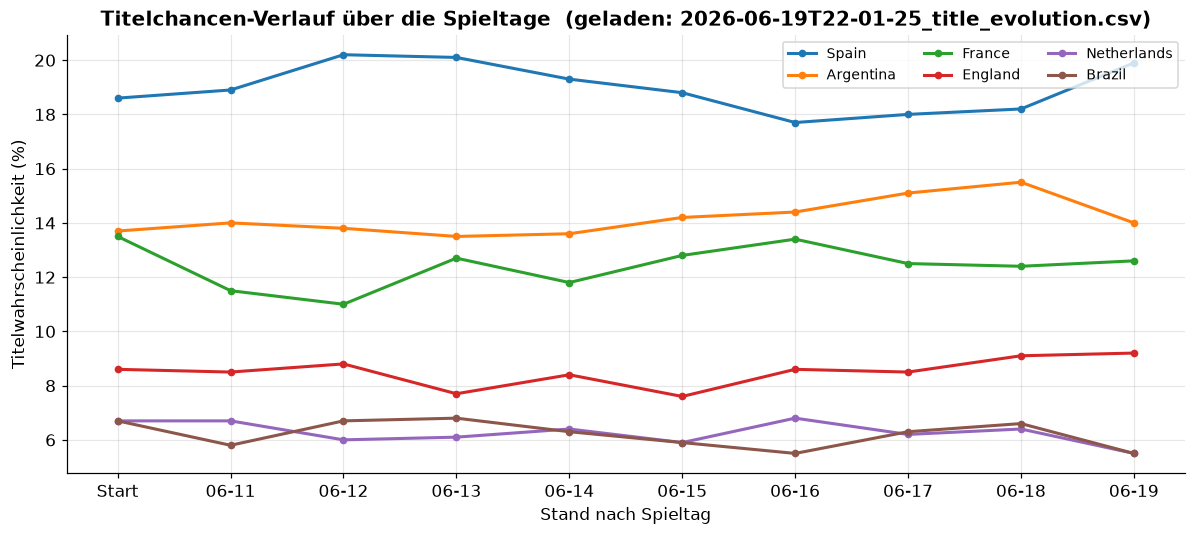

Interpretation: jede Linie zeigt, wie sich die Titelchance eines Teams mit den
real gespielten Ergebnissen verschoben hat (Start = reine Vor-Turnier-Prognose).


In [9]:
played_pairs = set(zip(played.home, played.away))
snap = sorted(glob.glob("results/*_next_matches.csv"))
print(f"Gespeicherte Prognose-Schnappschüsse (next_matches): {len(snap)}")
for f in snap[-4:]:
    df = pd.read_csv(f); ts = Path(f).name.split("_next")[0]
    pairs = [tuple(x.strip() for x in str(b).split(" – ")) for b in df.get("Begegnung", []) if " – " in str(b)]
    done = sum(1 for p in pairs if p in played_pairs)
    print(f"   {ts}: {len(pairs)} Prognosen gespeichert, davon {done} inzwischen gespielt")

# Titelchancen-Verlauf (geladen aus results/) — zeigt die Verschiebung je Spieltag
te = sorted(glob.glob("results/*_title_evolution.csv"))
if te:
    tev = pd.read_csv(te[-1]); cols = [c for c in tev.columns if c != "Stand"]
    fig, ax = plt.subplots(figsize=(11, 5))
    for c in cols: ax.plot(tev["Stand"], tev[c], "-o", lw=2, ms=4, label=c)
    ax.set_title(f"Titelchancen-Verlauf über die Spieltage  (geladen: {Path(te[-1]).name})")
    ax.set_ylabel("Titelwahrscheinlichkeit (%)"); ax.set_xlabel("Stand nach Spieltag")
    ax.legend(ncol=3, fontsize=9); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig("nb_eval_title_history.png"); plt.show()
    print("Interpretation: jede Linie zeigt, wie sich die Titelchance eines Teams mit den")
    print("real gespielten Ergebnissen verschoben hat (Start = reine Vor-Turnier-Prognose).")
else:
    print("\nKein *_title_evolution.csv in results/ — bitte zuerst wc2026_live_update.ipynb")
    print("ausführen (Run All); dann erscheinen hier die gespeicherten Verläufe.")

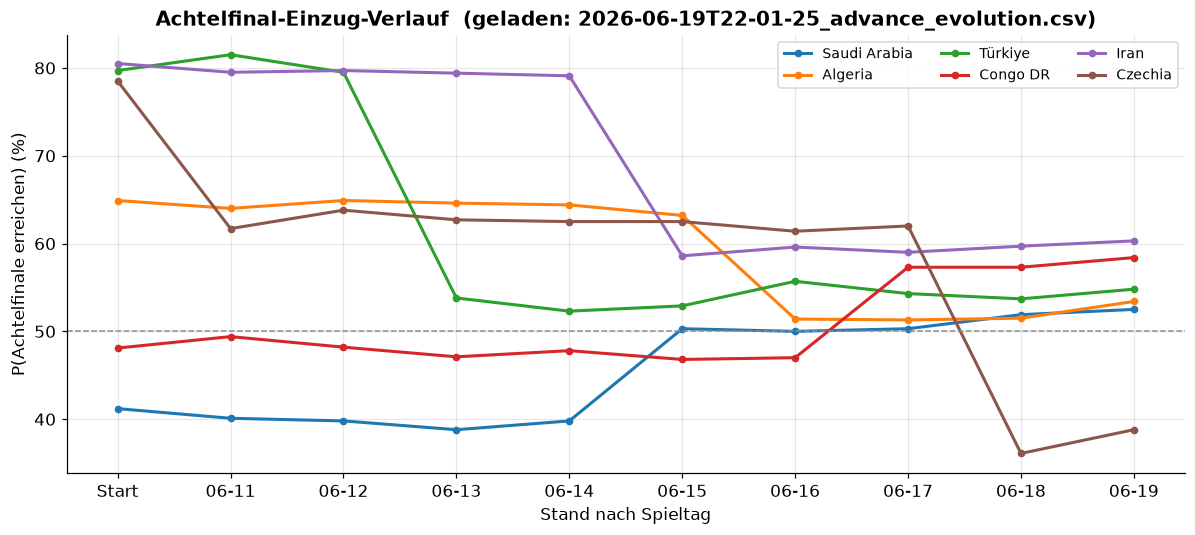

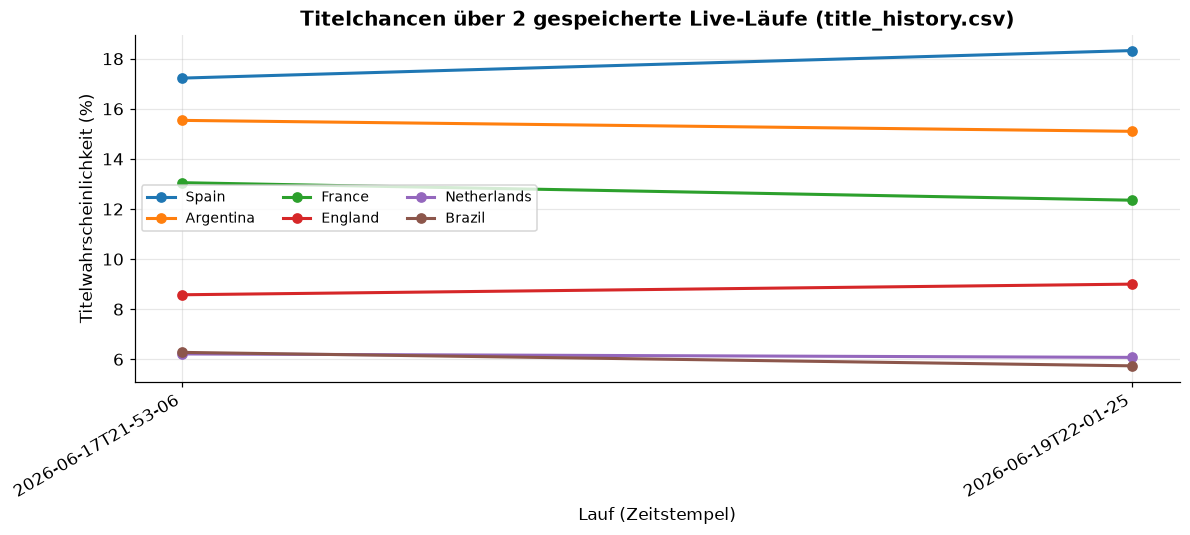

In [10]:
# Achtelfinal-Einzug-Verlauf + (falls mehrere Läufe) Verlauf ÜBER die Läufe
ae = sorted(glob.glob("results/*_advance_evolution.csv"))
if ae:
    aev = pd.read_csv(ae[-1]); cols = [c for c in aev.columns if c != "Stand"]
    fig, ax = plt.subplots(figsize=(11, 5))
    for c in cols: ax.plot(aev["Stand"], aev[c], "-o", lw=2, ms=4, label=c)
    ax.axhline(50, color=GREY, ls="--", lw=1)
    ax.set_title(f"Achtelfinal-Einzug-Verlauf  (geladen: {Path(ae[-1]).name})")
    ax.set_ylabel("P(Achtelfinale erreichen) (%)"); ax.set_xlabel("Stand nach Spieltag")
    ax.legend(ncol=3, fontsize=9); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig("nb_eval_advance_history.png"); plt.show()

hp = "results/title_history.csv"
if Path(hp).exists():
    th = pd.read_csv(hp); runs = th["run"].nunique()
    if runs > 1:
        piv = th.pivot_table(index="run", columns="Team", values="Titel")
        top = piv.iloc[-1].sort_values(ascending=False).head(6).index
        fig, ax = plt.subplots(figsize=(11, 5))
        for t in top: ax.plot(piv.index, piv[t], "-o", lw=2, label=t)
        ax.set_title(f"Titelchancen über {runs} gespeicherte Live-Läufe (title_history.csv)")
        ax.set_ylabel("Titelwahrscheinlichkeit (%)"); ax.set_xlabel("Lauf (Zeitstempel)")
        ax.legend(ncol=3, fontsize=9); ax.grid(alpha=.3); plt.xticks(rotation=30, ha="right")
        plt.tight_layout(); plt.savefig("nb_eval_run_history.png"); plt.show()
    else:
        print(f"title_history.csv: bisher {runs} Lauf gespeichert. Der Verlauf ÜBER mehrere")
        print("Läufe erscheint, sobald das Live-Notebook an mehreren Spieltagen lief")
        print("(jeweils: python refresh_data.py  ->  wc2026_live_update.ipynb Run All).")

## 8. Kontrolle aller gespeicherten Prognosen — pro Lauf & pro Spieltag

Damit du **nichts händisch** durchgehen musst: eine automatische Kontrolle.
Zuerst eine **Übersicht je gespeichertem Lauf** (`results/*_next_matches.csv`) —
wie viele Prognosen er enthält, wie viele davon inzwischen gespielt sind und wie
gut sie lagen. Danach eine **Spieltag-für-Spieltag-Bilanz** über alle gespielten
Spiele. Die vollständige Spiel-für-Spiel-Tabelle steht in **§3b**.

In [11]:
# --- Übersicht je gespeichertem Lauf (scannt alle results/*_next_matches.csv) ---
def eval_snapshot(path):
    df = pd.read_csv(path); rows = []
    for _, r in df.iterrows():
        b = str(r.get("Begegnung", ""))
        if " – " not in b: continue
        h, a = [x.strip() for x in b.split(" – ")]
        if (h, a) not in played_pairs: continue
        m = played[(played.home==h) & (played.away==a)].iloc[0]
        gh, ga = int(m.score1), int(m.score2)
        lh, la = [float(x) for x in str(r["Ø Tore (λ)"]).split(" : ")]
        pr = np.array([float(r["P(Sieg 1)"]), float(r["P(Remis)"]), float(r["P(Sieg 2)"])])
        tp = [1,0,-1][int(np.argmax(pr))]; ta = int(np.sign(gh-ga))
        rows.append(dict(wdl_ok=tp==ta, score_ok=str(r["wahrsch. Erg."])==f"{gh}:{ga}",
                         lam_err=abs(lh-gh)+abs(la-ga)))
    return pd.DataFrame(rows)

if not snap:
    print("Keine gespeicherten Snapshots in results/ — zuerst wc2026_live_update.ipynb ausführen.")
else:
    ov = []
    for f in snap:
        ts = Path(f).name.split("_next")[0]; df = pd.read_csv(f)
        npred = sum(1 for b in df.get("Begegnung", []) if " – " in str(b))
        e = eval_snapshot(f)
        ov.append(dict(Lauf=ts, Prognosen=npred, gespielt=len(e),
                       **({"Tendenz": f"{e.wdl_ok.mean()*100:.0f}%",
                           "Exakt": f"{e.score_ok.mean()*100:.0f}%",
                           "λ-MAE": f"{e.lam_err.mean():.2f}"} if len(e) else
                          {"Tendenz":"—","Exakt":"—","λ-MAE":"—"})))
    ov_df = pd.DataFrame(ov)
    display(ov_df.style.hide(axis="index")
            .set_caption("Pro gespeichertem Lauf: Prognosen, davon gespielt, und Trefferquoten"))
    if (ov_df["gespielt"] == 0).all():
        print("Hinweis: Die aktuell gespeicherten Snapshots betreffen noch ungespielte Spiele.")
        print("Die Spieltag-Bilanz unten nutzt daher die (statisch identischen) Prognosen")
        print("für alle bereits gespielten Spiele — sobald du das Live-Notebook vor weiteren")
        print("Spieltagen ausführst, füllen sich hier die Trefferquoten je Lauf.")

Lauf,Prognosen,gespielt,Tendenz,Exakt,λ-MAE
2026-06-17T21-53-06,51,8,88%,0%,2.29
2026-06-19T22-01-25,43,0,—,—,—


Datum,Spiele,Tendenz ✓,Ergebnis ✓,Tendenz %,Exakt %,λ-MAE
2026-06-11,2,1,0,50,0,1.19
2026-06-12,2,1,1,50,50,1.52
2026-06-13,4,1,1,25,25,1.32
2026-06-14,4,2,0,50,0,2.89
2026-06-15,4,0,0,0,0,1.69
2026-06-16,4,4,0,100,0,1.78
2026-06-17,4,3,0,75,0,1.92
2026-06-18,4,3,0,75,0,2.55
2026-06-19,1,1,0,100,0,1.60


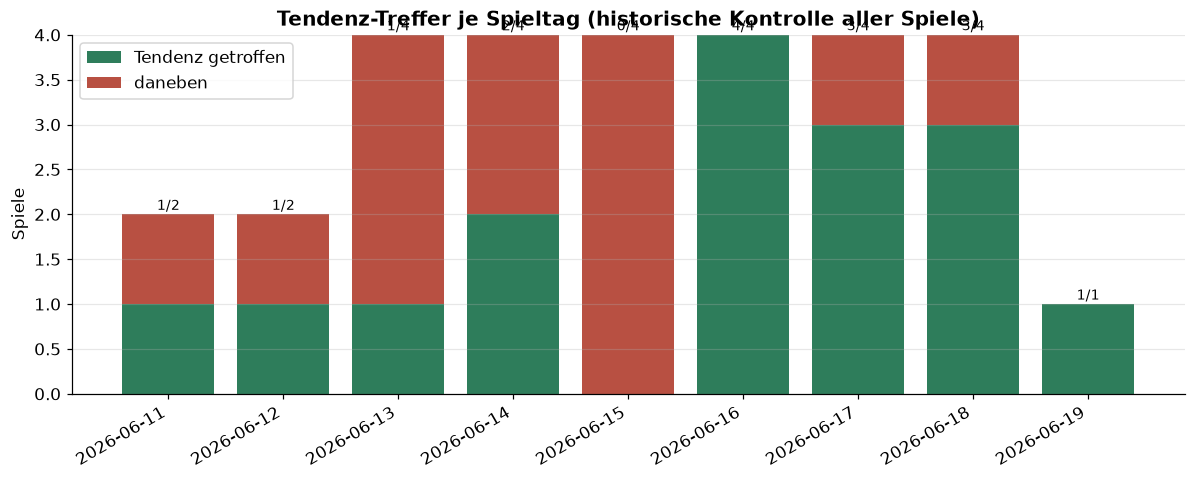

In [12]:
# --- Spieltag-für-Spieltag-Bilanz über ALLE gespielten Spiele ---
mtab = (ev.groupby("Datum")
          .agg(Spiele=("wdl_ok","size"), Tendenz_ok=("wdl_ok","sum"),
               Exakt_ok=("score_ok","sum"), lam_MAE=("lam_err","mean"))
          .reset_index())
mtab["Tendenz %"] = (mtab.Tendenz_ok/mtab.Spiele*100).round(0).astype(int)
mtab["Exakt %"]   = (mtab.Exakt_ok/mtab.Spiele*100).round(0).astype(int)
mtab["λ-MAE"]     = mtab.lam_MAE.round(2)
show = mtab[["Datum","Spiele","Tendenz_ok","Exakt_ok","Tendenz %","Exakt %","λ-MAE"]].rename(
        columns={"Tendenz_ok":"Tendenz ✓","Exakt_ok":"Ergebnis ✓"})
display(show.style.hide(axis="index")
        .background_gradient(cmap="RdYlGn", subset=["Tendenz %","Exakt %"])
        .background_gradient(cmap="RdYlGn_r", subset=["λ-MAE"])
        .format({"λ-MAE":"{:.2f}"})
        .set_caption("Spieltag-für-Spieltag: wie viele Spiele das Modell je Tag richtig lag (historisch)"))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = range(len(mtab))
ax.bar(x, mtab.Tendenz_ok, color=GREEN, label="Tendenz getroffen")
ax.bar(x, mtab.Spiele - mtab.Tendenz_ok, bottom=mtab.Tendenz_ok, color=RED, label="daneben")
for i, (s, t) in enumerate(zip(mtab.Spiele, mtab.Tendenz_ok)):
    ax.text(i, s+0.05, f"{t}/{s}", ha="center", fontsize=9)
ax.set_xticks(list(x)); ax.set_xticklabels(mtab.Datum, rotation=30, ha="right")
ax.set_ylabel("Spiele"); ax.set_title("Tendenz-Treffer je Spieltag (historische Kontrolle aller Spiele)")
ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.savefig("nb_eval_per_matchday.png"); plt.show()

## 9. Ergebnis speichern & Fazit

In [13]:
ev_out = ev[["Datum","Begegnung","src","lam_str","endstand","lam_err","tipp",
             "wdl_ok","modal","score_ok"]].copy()
ev_out.to_csv("prediction_eval_log.csv", index=False)
print("Gespeichert: prediction_eval_log.csv")
print(f"\nFazit (Stand: {len(ev)} Spiele):")
print(f"  · Tendenz (Sieg/Remis/Niederlage) korrekt: {ev.wdl_ok.mean()*100:.0f}%  (Zufall 33%)")
print(f"  · Exaktes Ergebnis getroffen:              {ev.score_ok.mean()*100:.0f}%")
print(f"  · λ-MAE (erwartete vs. echte Tore):        {ev.lam_err.mean():.2f}")

Gespeichert: prediction_eval_log.csv

Fazit (Stand: 29 Spiele):
  · Tendenz (Sieg/Remis/Niederlage) korrekt: 55%  (Zufall 33%)
  · Exaktes Ergebnis getroffen:              7%
  · λ-MAE (erwartete vs. echte Tore):        1.92


**Einordnung.** Die ersten WM-Spiele sind ein **kleines, varianzreiches**
Set — mit etlichen Überraschungen der 1. Runde (z. B. 0:0 Spanien–Kap Verde,
2:2 Niederlande–Japan). Tendenz-Quoten knapp über/um Zufallsniveau und niedrige
Exakt-Trefferquoten sind hier normal; mit jedem weiteren Spieltag
(`python refresh_data.py`, dann dieses Notebook erneut ausführen) wird die
Auswertung aussagekräftiger. Exakte Spielstände sind generell schwer zu treffen —
selbst das wahrscheinlichste Resultat hat meist nur ~12–15 % Wahrscheinlichkeit.

*Aus* **Soccer Analytics with Machine Learning** *(O'Reilly, 2026). Daten:
openfootball (Public Domain).*